# MADE: Masked Autoencoder for Distribution Estimation

### Curso Inteligencia Artificial Generativa

**Pablo Martínez Olmos, Vanessa Gómez Verdejo, Alejandro Lancho Serrano**

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~emipar/BBVA/INTRO/img/logo_uc3m_foot.jpg' width=400 />


[MADE](https://arxiv.org/abs/1502.03509) is a probabilistic autoregressive model designed to exploit potential dependencies among the components of an input vector X. It builds a separate predictive model for each element by leveraging the idea of autoregression—where elements are predicted based on others within the same input. MADE implements this through strategically masking certain connections in the neural network’s weight matrices, ensuring that each variable is only conditioned on a defined subset of others.

<img src='http://sergeiturukin.com/assets/2017-02-22-183010_479x494_scrot.png' width=400 />

In visual terms, this involves disabling (masking) the influence of certain pixels—such as those that come after a target pixel in a specified ordering—so that the model learns to base its prediction only on prior elements. While initial examples in the paper use a straightforward top-left to bottom-right pixel ordering, MADE generalizes this by supporting arbitrary orderings of the input dimensions. This flexibility is valuable because the true structure of dependencies within the input isn’t always known, and a fixed natural order might not capture it well. For example, it may be more informative to predict a particular pixel by referencing later-positioned pixels instead of just earlier ones.

## MADE over binarized MNIST

Now we import the toy database over which we deploy the model:

In [2]:
# Dependencies
import random
import numpy as np
import math

# Pytorch support
import torch as th
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision

from torchvision import transforms, datasets
from torchvision.utils import make_grid
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [3]:
# Define a custom transform for binarization
class Binarize(object):
    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def __call__(self, tensor):
        return (tensor > self.threshold).float()

# Compose transforms: ToTensor converts PIL image to [0,1] float tensor, Binarize thresholds it
transform = transforms.Compose([
    transforms.ToTensor(),
    Binarize(threshold=0.5)  # You can adjust the threshold if needed
])

# Load MNIST dataset with binarization applied
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
trainset = DataLoader(train_dataset, batch_size=64, shuffle=True)
testset = DataLoader(test_dataset, batch_size=64, shuffle=False)



In [4]:
# Check one batch
for images, labels in trainset:
    print("Batch image shape:", images.shape)
    print("Batch labels shape:", labels.shape)
    print("Unique pixel values in a sample image:", th.unique(images[0]))
    break

Batch image shape: torch.Size([64, 1, 28, 28])
Batch labels shape: torch.Size([64])
Unique pixel values in a sample image: tensor([0., 1.])


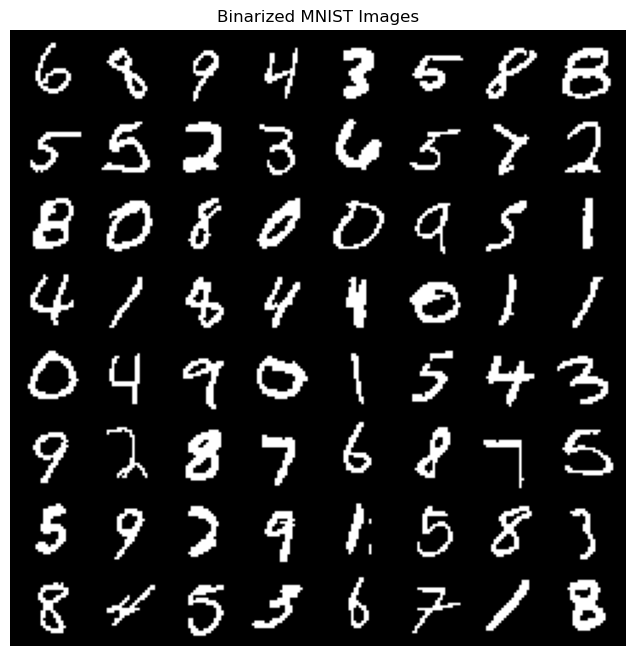

In [5]:
# Get a batch of images from the DataLoader
data_iter = iter(trainset)
images, labels = next(data_iter)

# Create a grid of images (8x8 by default)
grid_img = make_grid(images[:64], nrow=8, padding=2)

# Plot the grid
plt.figure(figsize=(8, 8))
plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
plt.title("Binarized MNIST Images")
plt.axis('off')
plt.show()

## MADE Implementation

The implementation is based on this [excellent repository](https://dosssman.github.io/posts/2020-07-28-made/). 

<img src='https://nsanghi.com/assets/images/2021-02-26-made/made-fig2.png'>




In [6]:
# Augmenting the nn.Linear to support masks
class MaskedLinear(nn.Linear):
    def __init__(self, in_features, out_features):
        super().__init__(in_features, out_features)
        self.register_buffer('mask', th.ones(out_features, in_features))  # default mask

    def set_mask(self, mask):
        self.mask = th.tensor(mask, dtype=self.weight.dtype, device=self.weight.device)

    def forward(self, input):
        return F.linear(input, self.mask * self.weight, self.bias)

In [7]:
# Hyper parameters
#SEED = 42
#N_EPOCHS = 10
#LR = 1e-3
#BATCH_SIZE = 128

HIDDEN_SIZES = [512,512]
LATENT_DIM = HIDDEN_SIZES[-1]

INPUT_DIM = 28**2
OUTPUT_DIM = 28**2

INPUT_ORDERINGS = 0
 # Input ordering meaning
#  0: Natural Order
#  1: A single input ordering but shuffled

CONNECTIVITY_ORDERINGS = 1
# connectivity Orderings
#  0: Equivalent to vanilla autoencoder
#  1..: Use specified amount of randomly generated masks.

RESAMPLE_INTERVAL = 20

# Seeding
SEED = 42
random.seed(SEED)
np.random.seed( SEED)

# Pytorch seeding
USE_GPU=True
device = th.device( "cuda" if th.cuda.is_available()and USE_GPU else "cpu")
th.manual_seed( SEED)
if device.type == "cuda":
    th.cuda.manual_seed_all(SEED)

This class implements a **Masked Autoencoder for Distribution Estimation (MADE)** architecture, designed to model high-dimensional data with autoregressive structure, such as images. The `EncoderDecoder` model combines a multi-layer perceptron (MLP) with **learned binary masks** that enforce autoregressive constraints—ensuring that each output dimension is conditionally dependent only on a subset of previous input dimensions.

The architecture is split into an **encoder** and a **decoder**, each made up of masked linear layers. Masks are generated to control the connectivity between layers based on input orderings and layer-specific connectivity constraints. These masks ensure that the autoregressive property is respected, i.e., that each output unit only uses information from permitted (preceding) input units.

Key features:

* **Custom input orderings** to allow flexible dependency structures.
* **Dynamic mask generation**, optionally randomized for efficiency and diversity.
* A forward pass that combines encoding (feature extraction) and decoding (output reconstruction) using nonlinear activations.
* The output is a **Bernoulli distribution** over each pixel, modeled via a sigmoid activation.

This structure allows MADE to efficiently learn complex joint distributions over input data like images, while maintaining tractable and parallelizable training via masked feedforward computation.

In [8]:
# Model

class EncoderDecoder(nn.Module):
    def __init__(self, USE_GPU=True,HIDDEN_SIZES =[512,512], SEED=42, INPUT_DIM=784, OUTPUT_DIM=784,CONNECTIVITY_ORDERINGS = 1, INPUT_ORDERINGS = 0):
        super().__init__()

        # Dynamic generating of mask and orderings for efficiency
        self.connectivity_ordering_seed = 0
        self.input_ordering_seed = 0

        # Pay attention to the "s"
        self.connectivity_orderings = CONNECTIVITY_ORDERINGS
        self.input_orderings = INPUT_ORDERINGS
        self.device = th.device( "cuda" if th.cuda.is_available()and USE_GPU else "cpu")


        self.input_dim = INPUT_DIM
        self.hidden_sizes = HIDDEN_SIZES
        self.output_dim = OUTPUT_DIM

        # MLP Layers
        self.encoder_layers = nn.ModuleList()
        self.decoder_layers = nn.ModuleList()

        # Hidden sizes presistent
        self.encoder_hiddens = self.hidden_sizes
        self.decoder_hiddens = self.hidden_sizes[::-1][1:]
        self.decoder_hiddens.append(self.input_dim)

        # This define d for each component of the input vector
        self.input_ordering = [ i for i in range(1,self.input_dim+1)] # m_0 in the paper


        current_dim = self.input_dim
        #current_input_orders = self.input_ordering # (m_l in the paper)

        ## Encoder layers
        for hsize in self.encoder_hiddens:
            # Linear layer with weights and biases included
            self.encoder_layers.append( MaskedLinear(current_dim, hsize))

            current_dim = hsize

        ## Decoder layers
        for hsize in self.decoder_hiddens:
            # Linear layer with weights and biases included
            self.decoder_layers.append( MaskedLinear(current_dim, hsize))

            current_dim = hsize

        ## Input ordering: if only using one random shuffling, do it here,
        # then skip it in the shuffling function for efficiency
        if self.input_orderings == 1:
            np.random.shuffle(self.input_ordering) #In-place!

        # Let's us know if the mask was generated at least once already, for efficiency when using a single connectivity ordering
        self.mask_generated = False

        self.generate_masks()

        self.to(self.device)

    def generate_masks(self):
        if self.mask_generated and self.connectivity_orderings == 1:
            return # Skips mask generation for efficiciency

        elif self.connectivity_orderings ==1:
            # Inspired from Andrej Karpathy's implementation.
            rng = np.random.RandomState(self.connectivity_ordering_seed)
            self.connectivity_ordering_seed = (self.connectivity_ordering_seed + 1) % self.connectivity_orderings

        else:
            raise NotImplementedError

        #current_dim = self.input_dim
        current_input_orders = self.input_ordering # (m_l in the paper)

        layer_connect_counts = []

        for layer_idx, hsize in enumerate(self.encoder_hiddens):
            # Fix #1: Make sure we do not sample connectivity count that are not in the previous layer,
            # since they won't be useful, and reduce the number of weights that are actually used for the esitmation
            layer_count_low = 1 if len(layer_connect_counts) == 0 else np.min(layer_connect_counts)
            layer_connect_counts = [rng.randint(low=layer_count_low,high=INPUT_DIM) for _ in range(hsize)]

            # Generating a mask for each layer and storing it
            mask = [[ 1 if layer_connect_counts[k] >= d else 0 for k in range(hsize)] for d in current_input_orders]
            #self.encoder_layers[layer_idx].set_mask(np.array(mask))
            self.encoder_layers[layer_idx].set_mask(np.array(mask).T)

            current_dim = hsize
            current_input_orders = layer_connect_counts

        # Decoder subsection
        for layer_idx, hsize in enumerate(self.decoder_hiddens):
            if layer_idx == len(self.decoder_hiddens)-1:
                layer_connect_counts = self.input_ordering
                mask = [[ 1 if layer_connect_counts[k] > d else 0 for k in range(hsize)] for d in current_input_orders]
            else:
                # Note: In case we did not reach the last layer, we still generate the mask as for the
                # encoder's layer !
                layer_count_low = 1 if len(layer_connect_counts) == 0 else np.min(layer_connect_counts)
                layer_connect_counts = [rng.randint(low=layer_count_low,high=self.input_dim) for _ in range(hsize)]

                # Generating a mask for each layer and storing it
                mask = [[ 1 if layer_connect_counts[k] >= d else 0 for k in range(hsize)] for d in current_input_orders]

            #self.decoder_layers[layer_idx].set_mask(np.array(mask))
            self.decoder_layers[layer_idx].set_mask(np.array(mask).T)

            current_input_orders = layer_connect_counts

        self.mask_generated = True

    def encode(self,x):
        for layer in self.encoder_layers:
            x = F.relu(layer(x))

        return x

    def decode(self,z):
        for layer in self.decoder_layers[:-1]:
            z = F.relu(layer(z))

        z = self.decoder_layers[-1](z)

        return th.sigmoid(z) #We return the probability per pixel

    def forward(self,x):
        # Full pass
        return self.decode(self.encode(x))


In [9]:
encdec = EncoderDecoder(INPUT_ORDERINGS = 1)

print( encdec)


EncoderDecoder(
  (encoder_layers): ModuleList(
    (0): MaskedLinear(in_features=784, out_features=512, bias=True)
    (1): MaskedLinear(in_features=512, out_features=512, bias=True)
  )
  (decoder_layers): ModuleList(
    (0): MaskedLinear(in_features=512, out_features=512, bias=True)
    (1): MaskedLinear(in_features=512, out_features=784, bias=True)
  )
)


We can access to the current masks easily ...

In [10]:
encdec.encoder_layers[0].mask

tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [0., 0., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]], device='cuda:0')

Now we augment the class with a training loop 

In [11]:
# Hyper parameters
SEED = 42
N_EPOCHS = 10
LR = 1e-3
BATCH_SIZE = 128

In [12]:
class TrainableEncoderDecoder(EncoderDecoder):
    def __init__(self, USE_GPU=True, HIDDEN_SIZES =[512,512], SEED=42,
                 INPUT_DIM=784, OUTPUT_DIM=784,CONNECTIVITY_ORDERINGS = 1,
                 INPUT_ORDERINGS = 0, LR=1e-3,BATCH_SIZE = 128, N_EPOCHS=10):
        super().__init__(USE_GPU, HIDDEN_SIZES, SEED, INPUT_DIM, OUTPUT_DIM,CONNECTIVITY_ORDERINGS, INPUT_ORDERINGS)

        self.lr = LR
        self.batch_size = BATCH_SIZE
        self.n_epochs = N_EPOCHS
        self.resample_interval = RESAMPLE_INTERVAL
        self.optimizer = optim.Adam(list(self.parameters()), lr=self.lr)

    def compute_loss(self, data):
        data = data.view(data.size(0), -1)
        x_pred = self(data)
        loss = F.binary_cross_entropy(x_pred, data)
        return loss

    def evaluate(self, testset):
        self.eval()
        loss = 0.
        with th.no_grad():
            for test_batch_idx, (data, _) in enumerate(testset):
                data = data.to(self.device)
                loss += self.compute_loss(data)
            loss /= (test_batch_idx + 1)
        self.train()
        return loss

    def train_model(self, trainset, testset):
        mb_train_losses = []
        test_losses = []
        batch_iter = 0

        # Test loss before trainning
        test_loss = self.evaluate(testset)
        test_losses.append(test_loss.item())

        for epoch in range(self.n_epochs):
            for mb_idx, (mb_train_data, _) in enumerate(trainset):
                mb_train_data = mb_train_data.to(self.device)
                mb_train_loss = self.compute_loss(mb_train_data)

                self.optimizer.zero_grad()
                mb_train_loss.backward()
                self.optimizer.step()

                mb_train_losses.append(mb_train_loss.item())
                batch_iter += 1


            test_loss = self.evaluate(testset)
            test_losses.append(test_loss.item())

            print(f"Epoch {epoch}: Train Loss: {mb_train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

        return mb_train_losses, test_losses, mb_idx

    def generate_samples(self, n_samples=100):
        self.eval()
        samples = th.rand((n_samples, self.input_dim), device=self.device)

        for i in range(self.input_dim):
            reconstructed = self(samples)
            binarized = th.bernoulli(reconstructed)
            samples[:, i] = binarized[:, i]

        samples = samples.view(n_samples, 1, 28, 28).cpu()
        grid_img = make_grid(samples, nrow=int(math.sqrt(n_samples)))
        plt.figure(figsize=(6, 6))
        plt.imshow(grid_img.permute(1, 2, 0).squeeze(), cmap='gray')
        plt.axis('off')
        plt.title("Generated Samples")
        plt.show()
        self.train()


In [13]:
encdec = TrainableEncoderDecoder(N_EPOCHS=30)

In [14]:
train_loss, test_loss, mb_idx = encdec.train_model(trainset,testset)

Epoch 0: Train Loss: 0.2068, Test Loss: 0.2016
Epoch 1: Train Loss: 0.1884, Test Loss: 0.1670
Epoch 2: Train Loss: 0.1449, Test Loss: 0.1508
Epoch 3: Train Loss: 0.1310, Test Loss: 0.1421
Epoch 4: Train Loss: 0.1395, Test Loss: 0.1369
Epoch 5: Train Loss: 0.1288, Test Loss: 0.1335
Epoch 6: Train Loss: 0.1271, Test Loss: 0.1301
Epoch 7: Train Loss: 0.1363, Test Loss: 0.1276
Epoch 8: Train Loss: 0.1247, Test Loss: 0.1262
Epoch 9: Train Loss: 0.1091, Test Loss: 0.1242
Epoch 10: Train Loss: 0.1170, Test Loss: 0.1227
Epoch 11: Train Loss: 0.1244, Test Loss: 0.1221
Epoch 12: Train Loss: 0.1106, Test Loss: 0.1210
Epoch 13: Train Loss: 0.1316, Test Loss: 0.1205
Epoch 14: Train Loss: 0.1075, Test Loss: 0.1197
Epoch 15: Train Loss: 0.1157, Test Loss: 0.1194
Epoch 16: Train Loss: 0.1162, Test Loss: 0.1186
Epoch 17: Train Loss: 0.1211, Test Loss: 0.1183
Epoch 18: Train Loss: 0.1138, Test Loss: 0.1181
Epoch 19: Train Loss: 0.1286, Test Loss: 0.1179
Epoch 20: Train Loss: 0.1138, Test Loss: 0.1174
Ep

Visualizemos la función de coste ...

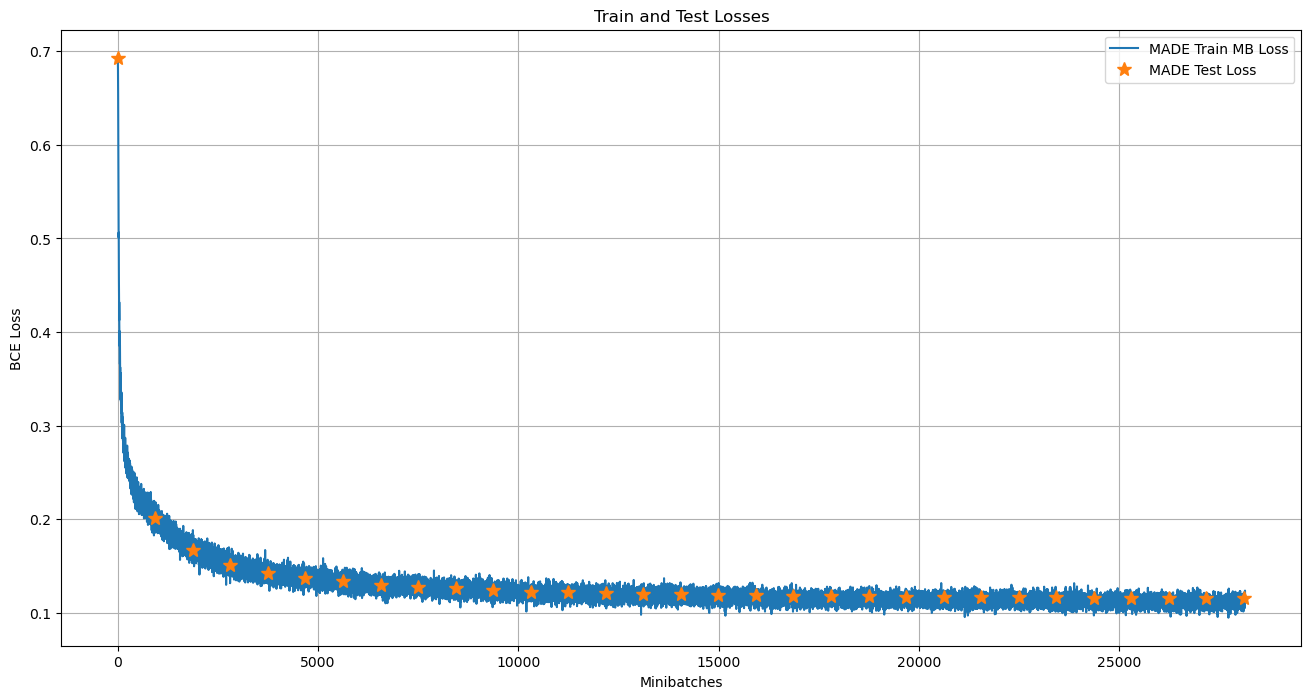

In [21]:
fig, axes = plt.subplots(1, 1, figsize=(16, 8))
x_mbs_train = np.arange(len(train_loss))
x_mbs_test = np.arange(0, len(train_loss), mb_idx)

axes.plot(x_mbs_train, train_loss, label="MADE Train MB Loss")
axes.plot(x_mbs_test, test_loss, marker='*', linestyle='None', label="MADE Test Loss", markersize=10)
axes.set_xlabel("Minibatches")
axes.set_ylabel("BCE Loss")
axes.set_title("Train and Test Losses")
axes.legend()
axes.grid(True)


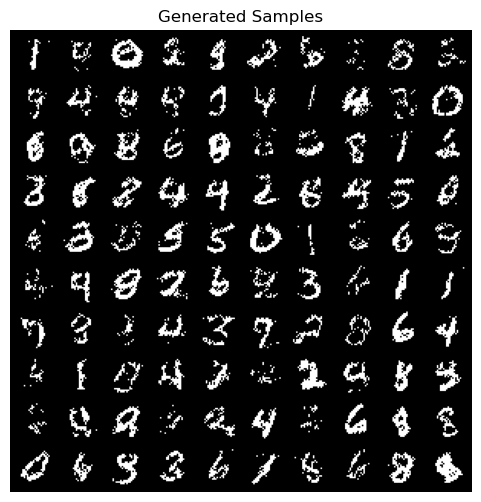

In [22]:
encdec.generate_samples()

### Missing data imputation

We can use the trained model to impute missing data (note we did not consider that during training in this implementation). To do so, we feed the current data input with 0s at missing positions to the model, and sample at the output ...

In [23]:
def impute_missing_pixels(model, testloader, n_samples=8, missing_ratio=0.5):
    model.eval()
    images, _ = next(iter(testloader))
    images = images[:n_samples].to(model.device)
    original_images = images.clone()

    flat_images = images.view(n_samples, -1)
    mask = (th.rand_like(flat_images) > missing_ratio).float()
    corrupted = flat_images * mask

    with th.no_grad():
        reconstructed = model(corrupted)

    # Blend: use original where not masked, model output where masked
    blended = reconstructed * (1 - mask) + flat_images * mask
    blended = blended.view(n_samples, 1, 28, 28)

    corrupted = corrupted.view(n_samples, 1, 28, 28)

    grid = th.cat([original_images.cpu(), corrupted.cpu(), blended.cpu()], dim=0)
    grid_img = torchvision.utils.make_grid(grid, nrow=n_samples)

    plt.figure(figsize=(15, 5))
    plt.imshow(grid_img.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.axis('off')
    plt.title("Top: Original | Middle: Corrupted | Bottom: Imputed (Original Pixels Kept)")
    plt.show()


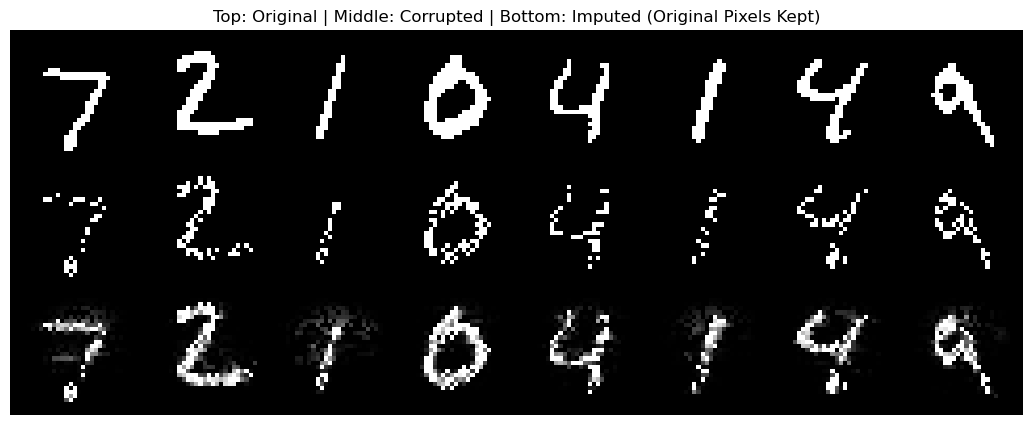

In [24]:
impute_missing_pixels(encdec, testset, n_samples=8, missing_ratio=0.5)


### Structure missing data imputation

Similarly we can proceed with missing not at random, such as masked regions ...

In [25]:
def impute_with_missing_square(model, testloader, K=5, n_samples=8):
    model.eval()
    images, _ = next(iter(testloader))
    images = images[:n_samples].to(model.device)
    original_images = images.clone()
    corrupted_images = images.clone()
    square_coords = []

    # Corrupt with square mask
    masks = th.ones_like(corrupted_images)
    for idx in range(n_samples):
        x = th.randint(0, 28 - K, (1,)).item()
        y = th.randint(0, 28 - K, (1,)).item()
        corrupted_images[idx, :, y:y+K, x:x+K] = 0.0
        masks[idx, :, y:y+K, x:x+K] = 0.0  # mark as masked
        square_coords.append((x, y))

    corrupted_flat = corrupted_images.view(n_samples, -1)
    mask_flat = masks.view(n_samples, -1)

    with th.no_grad():
        reconstructed = model(corrupted_flat)

    # Use model output only for masked pixels
    blended = reconstructed * (1 - mask_flat) + corrupted_flat * mask_flat
    blended = blended.view(n_samples, 1, 28, 28)

    # Plot original, corrupted (with red box), and imputed
    fig, axes = plt.subplots(3, n_samples, figsize=(2 * n_samples, 6))
    for i in range(n_samples):
        # Original
        axes[0, i].imshow(original_images[i, 0].cpu(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title("Original")

        # Corrupted + red square
        axes[1, i].imshow(corrupted_images[i, 0].cpu(), cmap='gray')
        x, y = square_coords[i]
        rect = patches.Rectangle((x, y), K, K, linewidth=1.5, edgecolor='red', facecolor='none')
        axes[1, i].add_patch(rect)
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title("Corrupted")

        # Reconstructed (with preserved original pixels)
        axes[2, i].imshow(blended[i, 0].cpu(), cmap='gray')
        axes[2, i].axis('off')
        if i == 0:
            axes[2, i].set_title("Imputed")

    plt.tight_layout()
    plt.show()


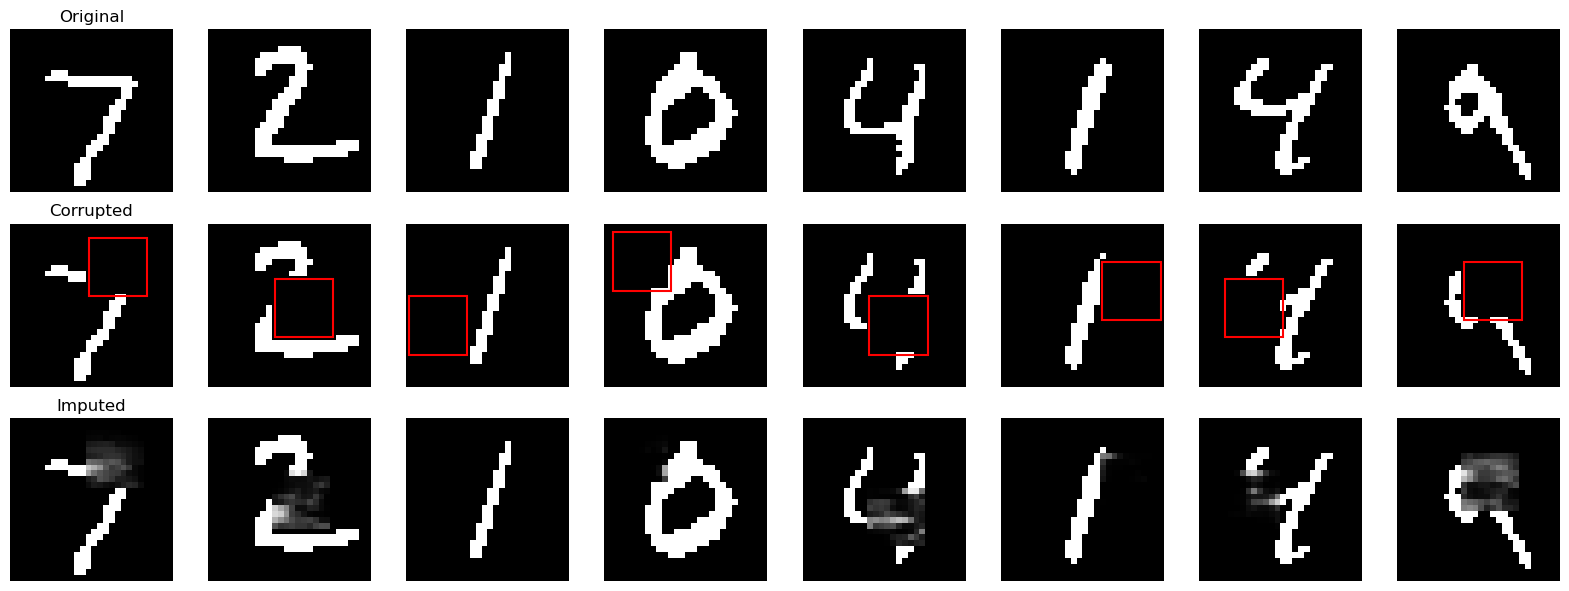

In [26]:
impute_with_missing_square(encdec, testset, K=10, n_samples=8)